# Grupo

    Enrico Najjar Galdeano
    10402924 


    Gabriel Shihao Chen Yin
    10408981
   
   
    Samuel Lopes Pereira
    10403767


# Síntese do conteúdo


O conteúdo consiste na preparação de dados para um algoritmo de recomendação de filmes. Começamos importando os datasets tmdb_5000_movies.csv e tmdb_5000_credits.csv. O código então limpa os dados, removendo colunas desnecessarias, e converte as colunas "genres" e "cast", que estão em formato JSON, em listas. Em seguida, os dois datasets são unidos. O processo final envolve a criação de listas binárias para gêneros, além da normalização de vote_average e release_year, o que transforma os dados em um formato numérico para uso em um modelo no algoritmo de K-Nearest Neighbors (KNN). O modelo utiliza três tipos de features: gêneros (encoding binário), nota média normalizada (vote_average) e ano de lançamento normalizado (release_year).


# Histórico de Atualizações

## Samuel Lopes Pereira

28/09 - Leitura dos arquivos CSV (tmdb_5000_movies.csv e tmdb_5000_credits.csv)

28/09 - Remoção de colunas irrelevantes (budget, homepage, production_companies, etc.)

28/09 - Análise exploratória inicial do dataset

29/09 - Consolidação de toda análise exploratória em uma única seção

29/09 - Remoção de seções duplicadas (verificações de nulos e duplicados)

29/09 - Expansão do resumo estatístico final com informações de todas as colunas

29/09 - Revisão e organização geral da estrutura do notebook

## Gabriel Shihao Chen Yin

28/09 - Transformação das colunas 'genres' e 'cast' de JSON para arrays Python

28/09 - Realização do inner join entre os datasets de filmes e créditos

28/09 - Verificação de valores duplicados e nulos no dataset

29/09 - Criação da função auxiliar find_movie_id() para busca por nome

29/09 - Modificação das funções de recomendação para aceitar nome do filme

29/09 - Implementação de busca parcial e case-insensitive para nomes de filmes

29/09 - Correção de bugs relacionados a tipos numpy nas funções

## Enrico Najjar Galdeano

28/09 - Remoção da coluna duplicada 'movie_id' após o merge

28/09 - Geração de listas únicas de gêneros e elenco para encoding

28/09 - Criação da função create_binary_list() para encoding binário

28/09 - Implementação do encoding binário para gêneros

29/09 - Otimização do cast (redução de dimensionalidade: 54.201 → 6.167 atores)

29/09 - Decisão sobre não utilizar cast no modelo final e documentação da justificativa

29/09 - Normalização de vote_average e release_year para o intervalo [0, 1]

29/09 - Preparação da matriz de features combinando gêneros, vote_average e release_year

29/09 - Treinamento do modelo KNN com métrica de cosseno

29/09 - Implementação das funções recommend_movies() e show_recommendations()

29/09 - Documentação sobre decisão de não usar outros atributos (keywords, original_language, overview, popularity, vote_count, runtime)


In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import warnings

# Suprimir avisos de depreciação do seaborn
warnings.filterwarnings('ignore', category=FutureWarning)

pd.options.display.max_rows = None
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Lendo arquivo com dados de filmes e ratings

In [182]:
df_movies = pd.read_csv('./dataset/tmdb_5000_movies.csv')
df_credits = pd.read_csv('./dataset/tmdb_5000_credits.csv')

# Removendo colunas irrelevantes

In [183]:
df_movies = df_movies.drop(columns=[
    'budget',
    'homepage',
    'production_companies',
    'production_countries',
    'spoken_languages',
    'status',
    'tagline',
    'original_title',
    'revenue'
])

df_credits = df_credits.drop(columns=['title','crew'])

# Mostrando 5 primeiros registros

In [184]:
df_movies.head(5)

,genres,id,keywords,original_language,overview,popularity,release_date,runtime,title,vote_average,vote_count
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,162.0,Avatar,7.2,11800
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,148.0,Spectre,6.3,4466
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,Following the death of District Attorney Harve...,112.312950,2012-07-16,165.0,The Dark Knight Rises,7.6,9106
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,"John Carter is a war-weary, former military ca...",43.926995,2012-03-07,132.0,John Carter,6.1,2124


In [185]:
df_credits.head(5)

,movie_id,cast
0,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""..."
1,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa..."
2,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr..."
3,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba..."
4,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c..."


# Transformando coluna genre para array

In [186]:
import json

def parse_genres(genres_str):
    try:
        genres_list = json.loads(genres_str)
        return [genre['name'] for genre in genres_list]
    except:
        return []

df_movies['genres'] = df_movies['genres'].apply(parse_genres)
display(df_movies.head())

,genres,id,keywords,original_language,overview,popularity,release_date,runtime,title,vote_average,vote_count
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,162.0,Avatar,7.2,11800
1,"[Adventure, Fantasy, Action]",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500
2,"[Action, Adventure, Crime]",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,148.0,Spectre,6.3,4466
3,"[Action, Crime, Drama, Thriller]",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,Following the death of District Attorney Harve...,112.312950,2012-07-16,165.0,The Dark Knight Rises,7.6,9106
4,"[Action, Adventure, Science Fiction]",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,"John Carter is a war-weary, former military ca...",43.926995,2012-03-07,132.0,John Carter,6.1,2124


# Transformando a coluna cast para um array

In [187]:
import json

def parse_cast(cast_str):
    try:
        cast_list = json.loads(cast_str)
        return [cast_member['name'] for cast_member in cast_list]
    except:
        return []

df_credits['cast'] = df_credits['cast'].apply(parse_cast)
display(df_credits.head())

,movie_id,cast
0,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave..."
1,285,"[Johnny Depp, Orlando Bloom, Keira Knightley, ..."
2,206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R..."
3,49026,"[Christian Bale, Michael Caine, Gary Oldman, A..."
4,49529,"[Taylor Kitsch, Lynn Collins, Samantha Morton,..."


# Inner join dos datasets

In [188]:
df_merged = pd.merge(df_movies, df_credits, left_on='id', right_on='movie_id', how='inner')
display(df_merged.head())

,genres,id,keywords,original_language,overview,popularity,release_date,runtime,title,vote_average,vote_count,movie_id,cast
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,162.0,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave..."
1,"[Adventure, Fantasy, Action]",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[Johnny Depp, Orlando Bloom, Keira Knightley, ..."
2,"[Action, Adventure, Crime]",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,148.0,Spectre,6.3,4466,206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R..."
3,"[Action, Crime, Drama, Thriller]",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,Following the death of District Attorney Harve...,112.312950,2012-07-16,165.0,The Dark Knight Rises,7.6,9106,49026,"[Christian Bale, Michael Caine, Gary Oldman, A..."
4,"[Action, Adventure, Science Fiction]",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,"John Carter is a war-weary, former military ca...",43.926995,2012-03-07,132.0,John Carter,6.1,2124,49529,"[Taylor Kitsch, Lynn Collins, Samantha Morton,..."


# Removendo coluna duplicada id

## Carregando Títulos dos Filmes


In [189]:
# Carregar títulos do dataset original para exibição nas recomendações
df_movies_titles = pd.read_csv('./dataset/tmdb_5000_movies.csv')[['id', 'title']]
movie_titles_dict = dict(zip(df_movies_titles['id'], df_movies_titles['title']))

print(f"Títulos carregados: {len(movie_titles_dict)} filmes")
print(f"\nExemplos:")
for i, (movie_id, title) in enumerate(list(movie_titles_dict.items())[:5]):
    print(f"  ID {movie_id}: {title}")


Títulos carregados: 4803 filmes

Exemplos:
  ID 19995: Avatar
  ID 285: Pirates of the Caribbean: At World's End
  ID 206647: Spectre
  ID 49026: The Dark Knight Rises
  ID 49529: John Carter


In [190]:
df_merged = df_merged.drop(columns=['movie_id'])
display(df_merged.head())

,genres,id,keywords,original_language,overview,popularity,release_date,runtime,title,vote_average,vote_count,cast
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,162.0,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weave..."
1,"[Adventure, Fantasy, Action]",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley, ..."
2,"[Action, Adventure, Crime]",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,148.0,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R..."
3,"[Action, Crime, Drama, Thriller]",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,Following the death of District Attorney Harve...,112.312950,2012-07-16,165.0,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman, A..."
4,"[Action, Adventure, Science Fiction]",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,"John Carter is a war-weary, former military ca...",43.926995,2012-03-07,132.0,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton,..."


# Análise Exploratória dos Dados 


## Informações Gerais do Dataset


In [191]:
# Informações gerais sobre o dataset
print(f"Dimensões do dataset: {df_merged.shape[0]} linhas x {df_merged.shape[1]} colunas")
print(f"\nColunas disponíveis: {list(df_merged.columns)}")
print("\nTipos de dados:")
print(df_merged.dtypes)
print("\nInformações detalhadas:")
df_merged.info()


Dimensões do dataset: 4803 linhas x 12 colunas

Colunas disponíveis: ['genres', 'id', 'keywords', 'original_language', 'overview', 'popularity', 'release_date', 'runtime', 'title', 'vote_average', 'vote_count', 'cast']

Tipos de dados:
genres                object
id                     int64
keywords              object
original_language     object
overview              object
popularity           float64
release_date          object
runtime              float64
title                 object
vote_average         float64
vote_count             int64
cast                  object
dtype: object

Informações detalhadas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genres             4803 non-null   object 
 1   id                 4803 non-null   int64  
 2   keywords           4803 non-null   object 
 3   original_language  4803 n

## Análise de Valores Nulos


Colunas com valores nulos:


,Coluna,Valores Nulos,Percentual (%)
4,overview,3,0.062461
7,runtime,2,0.041641
6,release_date,1,0.020820


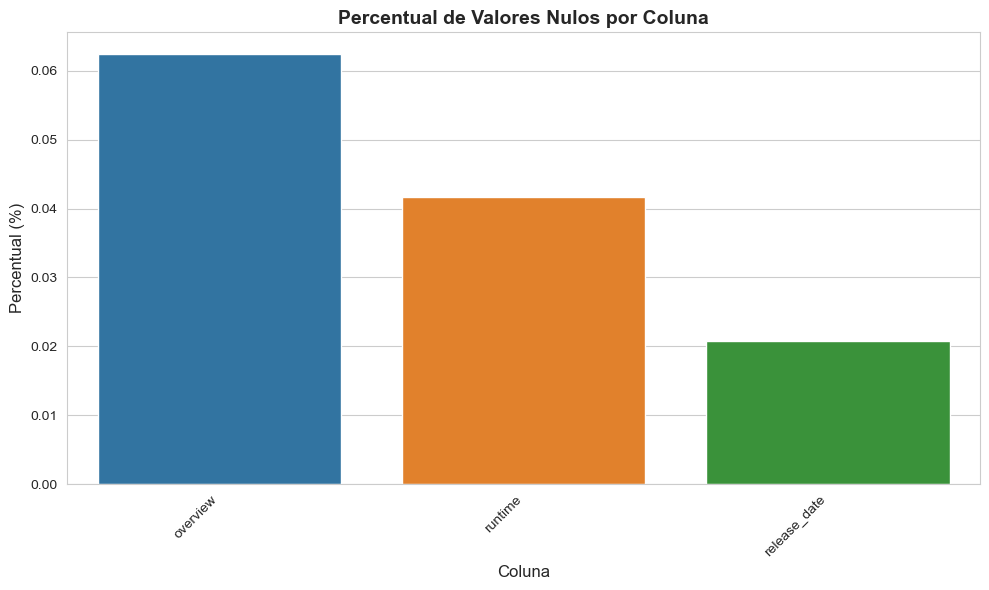

In [192]:
# Análise de valores nulos
null_counts = df_merged.isnull().sum()
null_percentage = (df_merged.isnull().sum() / len(df_merged)) * 100

null_df = pd.DataFrame({
    'Coluna': null_counts.index,
    'Valores Nulos': null_counts.values,
    'Percentual (%)': null_percentage.values
})
null_df = null_df[null_df['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

if len(null_df) > 0:
    print("Colunas com valores nulos:")
    display(null_df)
    
    # Visualização de valores nulos
    plt.figure(figsize=(10, 6))
    sns.barplot(data=null_df, x='Coluna', y='Percentual (%)')
    plt.title('Percentual de Valores Nulos por Coluna', fontsize=14, fontweight='bold')
    plt.xlabel('Coluna', fontsize=12)
    plt.ylabel('Percentual (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor nulo encontrado no dataset!")


## Análise de Registros Duplicados


In [193]:
# Análise de duplicatas
duplicated_count = df_merged['id'].duplicated().sum()
print(f"Número de IDs duplicados: {duplicated_count}")

if duplicated_count > 0:
    print("\nIDs duplicados:")
    duplicated_ids = df_merged[df_merged['id'].duplicated(keep=False)]['id'].unique()
    print(duplicated_ids)
else:
    print("Nenhum ID duplicado encontrado")


Número de IDs duplicados: 0
Nenhum ID duplicado encontrado


## Análise de Gêneros


Total de gêneros únicos: 20
Total de ocorrências de gêneros: 12160


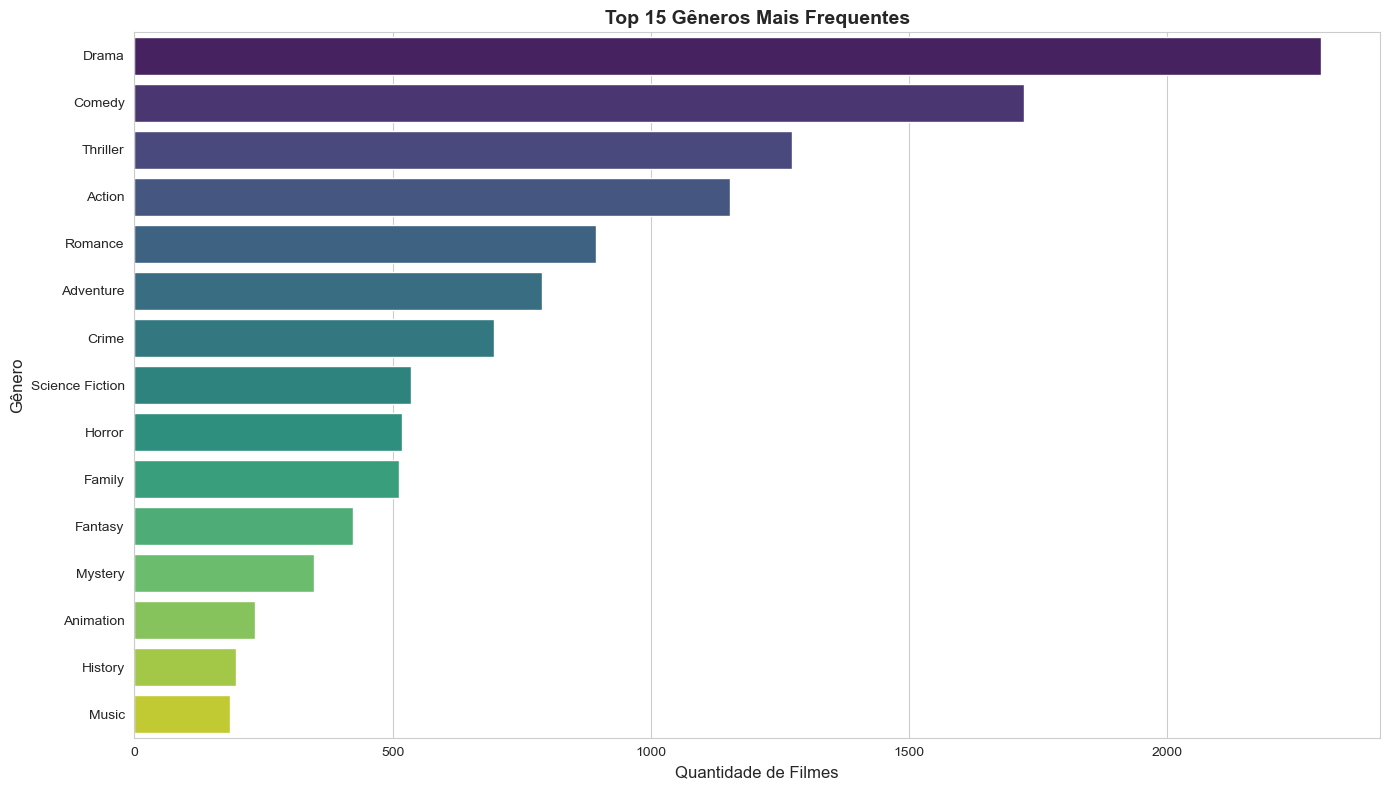


Estatísticas sobre número de gêneros por filme:
Média: 2.53
Mediana: 2.00
Mínimo: 0
Máximo: 7


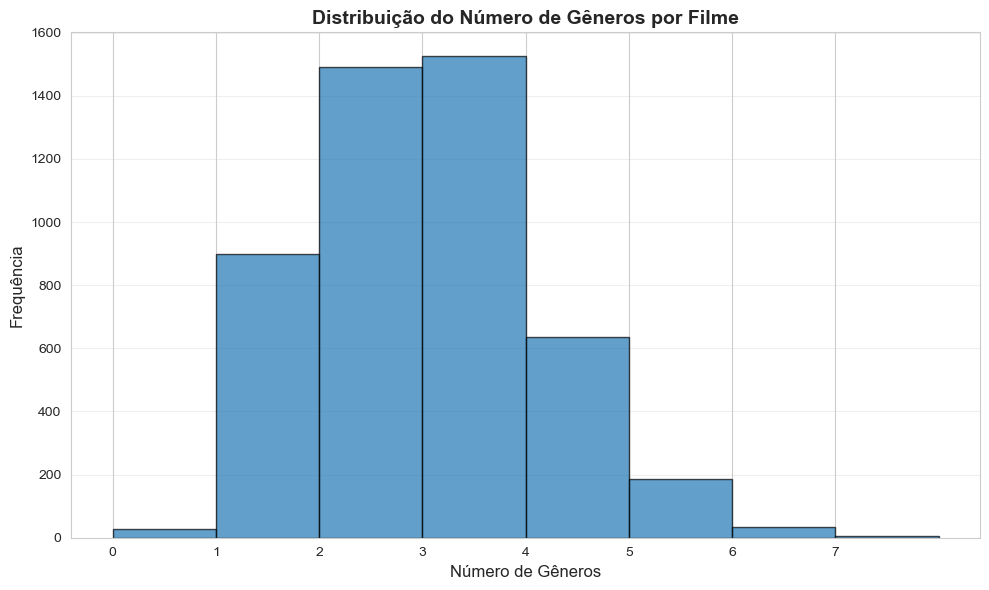

In [194]:
# Análise de Gêneros
# Coletando todos os gêneros
all_genres_list = []
for genres in df_merged['genres']:
    if isinstance(genres, list):
        all_genres_list.extend(genres)

# Contagem de gêneros
genre_counts = Counter(all_genres_list)
genre_df = pd.DataFrame(list(genre_counts.items()), columns=['Gênero', 'Quantidade'])
genre_df = genre_df.sort_values('Quantidade', ascending=False)

print(f"Total de gêneros únicos: {len(genre_df)}")
print(f"Total de ocorrências de gêneros: {len(all_genres_list)}")


# Visualização dos gêneros
plt.figure(figsize=(14, 8))
top_genres = genre_df.head(15)
sns.barplot(data=top_genres, x='Quantidade', y='Gênero', palette='viridis')
plt.title('Top 15 Gêneros Mais Frequentes', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Filmes', fontsize=12)
plt.ylabel('Gênero', fontsize=12)
plt.tight_layout()
plt.show()

# Distribuição do número de gêneros por filme
num_genres_per_movie = df_merged['genres'].apply(lambda x: len(x) if isinstance(x, list) else 0)
print(f"\nEstatísticas sobre número de gêneros por filme:")
print(f"Média: {num_genres_per_movie.mean():.2f}")
print(f"Mediana: {num_genres_per_movie.median():.2f}")
print(f"Mínimo: {num_genres_per_movie.min()}")
print(f"Máximo: {num_genres_per_movie.max()}")

plt.figure(figsize=(10, 6))
plt.hist(num_genres_per_movie, bins=range(0, num_genres_per_movie.max()+2), edgecolor='black', alpha=0.7)
plt.title('Distribuição do Número de Gêneros por Filme', fontsize=14, fontweight='bold')
plt.xlabel('Número de Gêneros', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.xticks(range(0, num_genres_per_movie.max()+1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Análise de Elenco (Cast)


Total de atores/atrizes únicos: 54201
Total de ocorrências de atores: 106257

Top 20 atores/atrizes mais frequentes:


,Ator/Atriz,Quantidade
541,Samuel L. Jackson,67
8247,Robert De Niro,57
5423,Bruce Willis,51
4007,Matt Damon,48
205,Morgan Freeman,46
1776,Steve Buscemi,43
208,Liam Neeson,41
83,Johnny Depp,40
2076,Owen Wilson,40
4388,Alec Baldwin,39


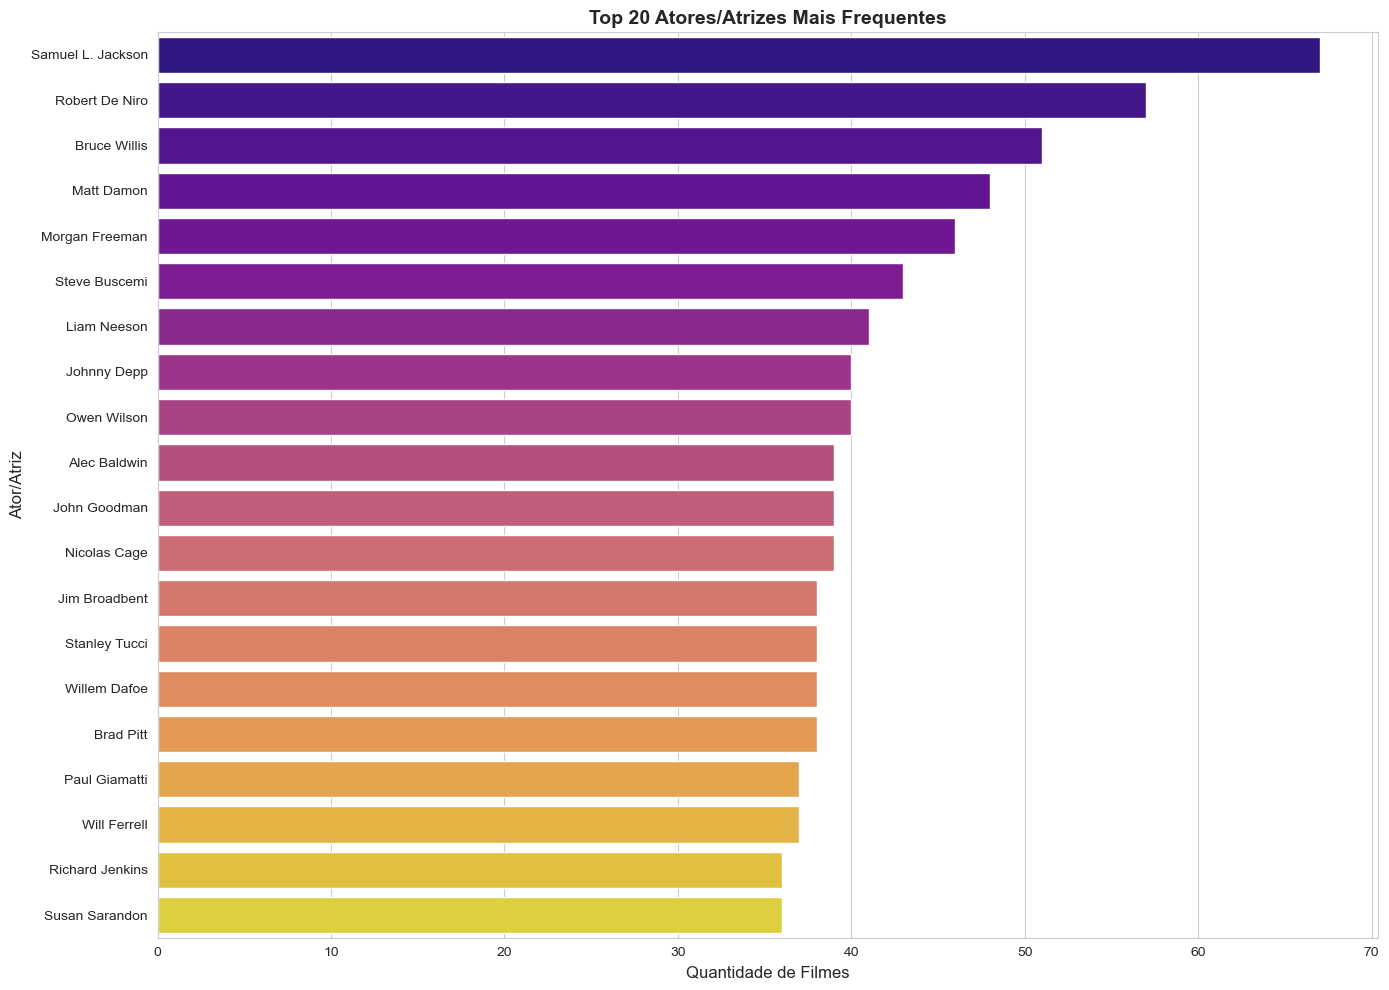


Estatísticas sobre número de atores por filme:
Média: 22.12
Mediana: 16.00
Mínimo: 0
Máximo: 224


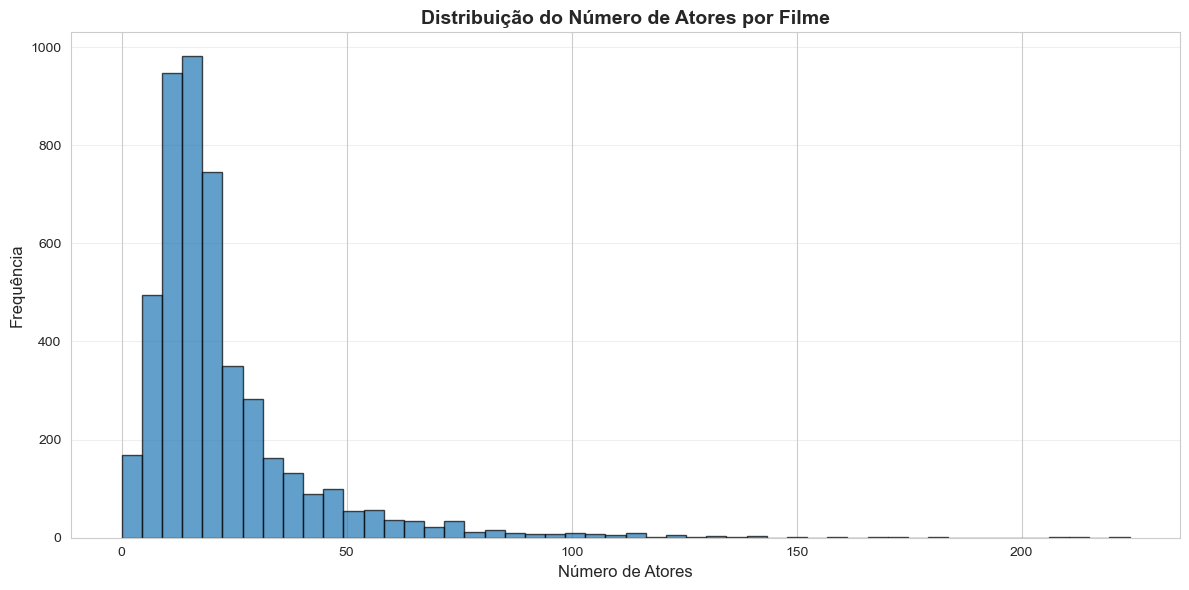

In [195]:
# Análise de Elenco (Cast)
# Coletando todos os atores
all_cast_list = []
for cast in df_merged['cast']:
    if isinstance(cast, list):
        all_cast_list.extend(cast)

# Contagem de atores
cast_counts = Counter(all_cast_list)
cast_df = pd.DataFrame(list(cast_counts.items()), columns=['Ator/Atriz', 'Quantidade'])
cast_df = cast_df.sort_values('Quantidade', ascending=False)

print(f"Total de atores/atrizes únicos: {len(cast_df)}")
print(f"Total de ocorrências de atores: {len(all_cast_list)}")
print(f"\nTop 20 atores/atrizes mais frequentes:")
display(cast_df.head(20))

# Visualização dos atores mais frequentes
plt.figure(figsize=(14, 10))
top_cast = cast_df.head(20)
sns.barplot(data=top_cast, x='Quantidade', y='Ator/Atriz', palette='plasma')
plt.title('Top 20 Atores/Atrizes Mais Frequentes', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Filmes', fontsize=12)
plt.ylabel('Ator/Atriz', fontsize=12)
plt.tight_layout()
plt.show()

# Distribuição do número de atores por filme
num_cast_per_movie = df_merged['cast'].apply(lambda x: len(x) if isinstance(x, list) else 0)
print(f"\nEstatísticas sobre número de atores por filme:")
print(f"Média: {num_cast_per_movie.mean():.2f}")
print(f"Mediana: {num_cast_per_movie.median():.2f}")
print(f"Mínimo: {num_cast_per_movie.min()}")
print(f"Máximo: {num_cast_per_movie.max()}")

plt.figure(figsize=(12, 6))
plt.hist(num_cast_per_movie, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribuição do Número de Atores por Filme', fontsize=14, fontweight='bold')
plt.xlabel('Número de Atores', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Análise de Atributos Numéricos e Temporais


Estatísticas descritivas de atributos numéricos:
        popularity  vote_average    vote_count      runtime
count  4803.000000   4803.000000   4803.000000  4801.000000
mean     21.492301      6.092172    690.217989   106.875859
std      31.816650      1.194612   1234.585891    22.611935
min       0.000000      0.000000      0.000000     0.000000
25%       4.668070      5.600000     54.000000    94.000000
50%      12.921594      6.200000    235.000000   103.000000
75%      28.313505      6.800000    737.000000   118.000000
max     875.581305     10.000000  13752.000000   338.000000


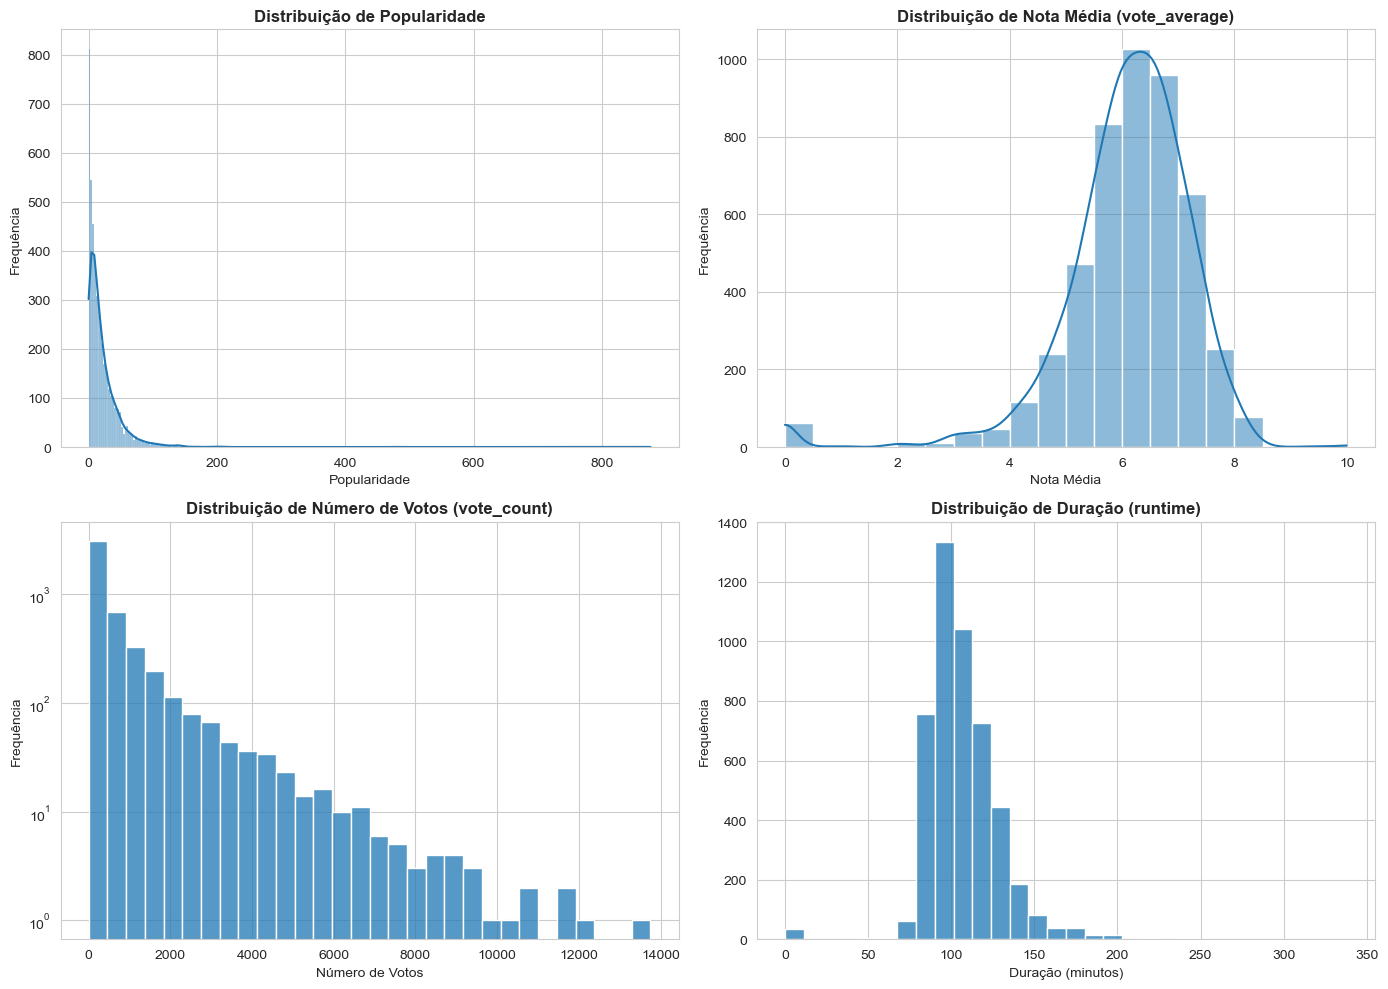


Estatísticas do ano de lançamento:
count    4802.000000
mean     2002.468763
std        12.414354
min      1916.000000
25%      1999.000000
50%      2005.000000
75%      2011.000000
max      2017.000000
Name: release_year, dtype: float64


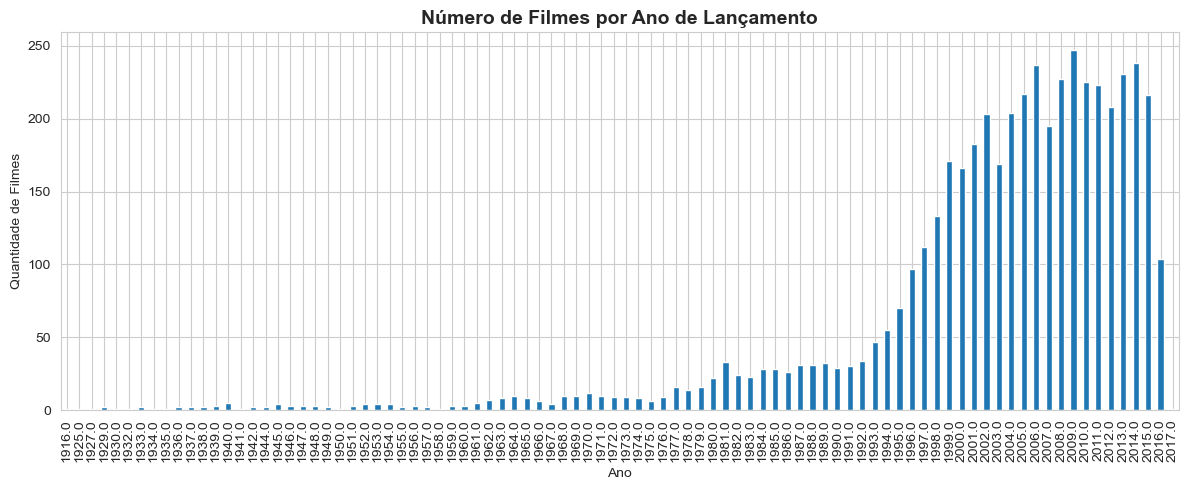


Top 10 idiomas originais:
original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ru      11
Name: count, dtype: int64


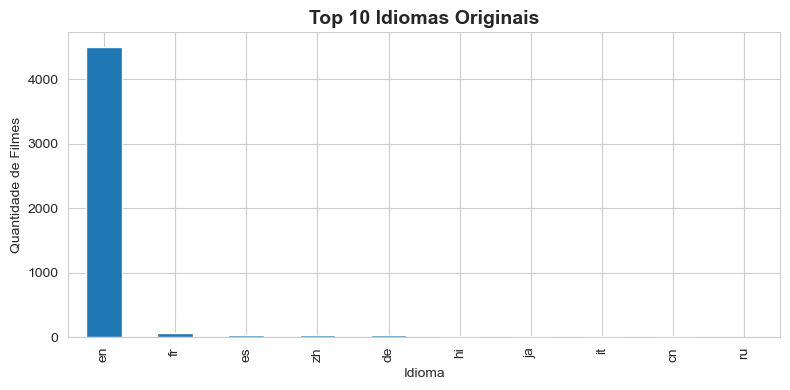


Análise de tamanho da sinopse (overview):
count    4803.000000
mean      305.207995
std       162.886559
min         0.000000
25%       177.500000
50%       283.000000
75%       392.000000
max      1000.000000
Name: overview_len, dtype: float64


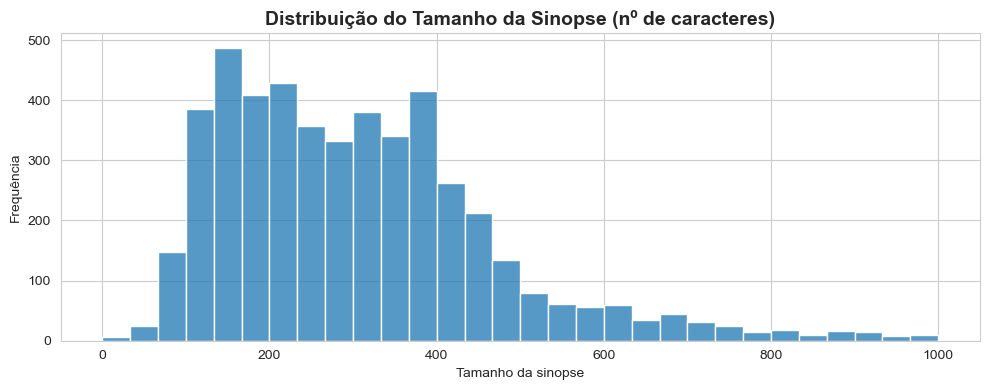


Quantidade de termos em keywords por filme:
count    4803.000000
mean       34.048511
std        28.357977
min         1.000000
25%        14.000000
50%        28.000000
75%        48.000000
max       481.000000
Name: keywords_len, dtype: float64


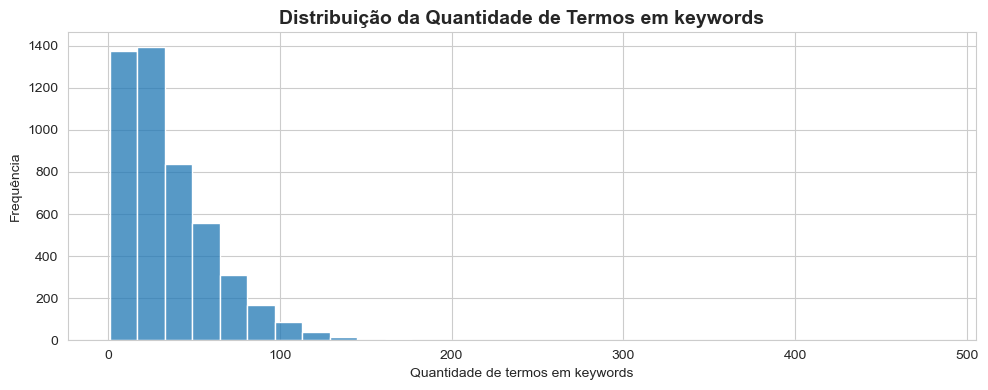

In [196]:
# Análise de atributos numéricos e temporais do df_movies

num_cols = ['popularity', 'vote_average', 'vote_count', 'runtime']
print("Estatísticas descritivas de atributos numéricos:")
print(df_movies[num_cols].describe())

# Distribuições
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

sns.histplot(df_movies['popularity'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Popularidade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Popularidade')
axes[0].set_ylabel('Frequência')

sns.histplot(df_movies['vote_average'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Nota Média (vote_average)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nota Média')
axes[1].set_ylabel('Frequência')

sns.histplot(df_movies['vote_count'], bins=30, ax=axes[2])
axes[2].set_title('Distribuição de Número de Votos (vote_count)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Número de Votos')
axes[2].set_ylabel('Frequência')
axes[2].set_yscale('log')

sns.histplot(df_movies['runtime'].dropna(), bins=30, ax=axes[3])
axes[3].set_title('Distribuição de Duração (runtime)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Duração (minutos)')
axes[3].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Extraindo ano de lançamento
df_movies['release_year'] = pd.to_datetime(df_movies['release_date'], errors='coerce').dt.year

print("\nEstatísticas do ano de lançamento:")
print(df_movies['release_year'].describe())

plt.figure(figsize=(12, 5))
movies_per_year = df_movies['release_year'].value_counts().sort_index()
movies_per_year.plot(kind='bar')
plt.title('Número de Filmes por Ano de Lançamento', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Filmes')
plt.tight_layout()
plt.show()

# Idioma original
print("\nTop 10 idiomas originais:")
print(df_movies['original_language'].value_counts().head(10))

plt.figure(figsize=(8, 4))
(df_movies['original_language']
   .value_counts()
   .head(10)
   .plot(kind='bar'))
plt.title('Top 10 Idiomas Originais', fontsize=14, fontweight='bold')
plt.xlabel('Idioma')
plt.ylabel('Quantidade de Filmes')
plt.tight_layout()
plt.show()

# Tamanho médio da sinopse (overview)
print("\nAnálise de tamanho da sinopse (overview):")
df_movies['overview_len'] = df_movies['overview'].fillna('').apply(len)
print(df_movies['overview_len'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df_movies['overview_len'], bins=30)
plt.title('Distribuição do Tamanho da Sinopse (nº de caracteres)', fontsize=14, fontweight='bold')
plt.xlabel('Tamanho da sinopse')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Quantidade de keywords por filme
if 'keywords' in df_movies.columns:
    df_movies['keywords_len'] = df_movies['keywords'].fillna('').astype(str).apply(lambda x: len(x.split()))
    print("\nQuantidade de termos em keywords por filme:")
    print(df_movies['keywords_len'].describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(df_movies['keywords_len'], bins=30)
    plt.title('Distribuição da Quantidade de Termos em keywords', fontsize=14, fontweight='bold')
    plt.xlabel('Quantidade de termos em keywords')
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()


## Amostras Aleatórias do Dataset


In [197]:
# Análise de amostras aleatórias
print("5 amostras aleatórias:")
display(df_merged.sample(5, random_state=42))


5 amostras aleatórias:


,genres,id,keywords,original_language,overview,popularity,release_date,runtime,title,vote_average,vote_count,cast
596,"[Action, Adventure, Comedy, Thriller]",8427,"[{""id"": 810, ""name"": ""budapest""}, {""id"": 1930,...",en,"When the Switchblade, the most sophisticated p...",13.267631,2002-10-31,97.0,I Spy,5.2,269,"[Eddie Murphy, Owen Wilson, Famke Janssen, Kei..."
3372,"[Thriller, Action, Horror, Science Fiction, Cr...",13006,"[{""id"": 3528, ""name"": ""flooding""}, {""id"": 9685...",en,"In a futuristic London, the rising sea levels ...",4.857028,1992-05-01,90.0,Split Second,5.7,63,"[Rutger Hauer, Kim Cattrall, Michael J. Pollar..."
2702,"[Drama, Mystery, Thriller]",18041,"[{""id"": 3616, ""name"": ""college""}, {""id"": 9937,...",en,"On a beautiful college campus, something ugly ...",5.833687,2000-04-21,90.0,Gossip,5.5,68,"[Joshua Jackson, James Marsden, Kate Hudson, L..."
2473,"[Drama, Romance]",5038,"[{""id"": 107, ""name"": ""barcelona spain""}, {""id""...",en,Two girlfriends on a summer holiday in Spain b...,32.758254,2008-08-15,96.0,Vicky Cristina Barcelona,6.7,1020,"[Scarlett Johansson, Rebecca Hall, Javier Bard..."
8,"[Adventure, Fantasy, Family]",767,"[{""id"": 616, ""name"": ""witch""}, {""id"": 2343, ""n...",en,"As Harry begins his sixth year at Hogwarts, he...",98.885637,2009-07-07,153.0,Harry Potter and the Half-Blood Prince,7.4,5293,"[Daniel Radcliffe, Rupert Grint, Emma Watson, ..."


## Resumo Estatístico Final


In [198]:
# Resumo estatístico final do dataset
print("="*60)
print("RESUMO ESTATÍSTICO FINAL")
print("="*60)

print(f"\nDIMENSÕES DO DATASET:")
print(f"  Total de filmes: {len(df_merged)}")
print(f"  Total de colunas: {df_merged.shape[1]}")

print(f"\nGÊNEROS:")
print(f"  Total de gêneros únicos: {len(genre_df)}")
print(f"  Média de gêneros por filme: {num_genres_per_movie.mean():.2f}")
print(f"  Mediana de gêneros por filme: {num_genres_per_movie.median():.0f}")
print(f"  Filme com mais gêneros: {num_genres_per_movie.max()} gêneros")
print(f"  Filme com menos gêneros: {num_genres_per_movie.min()} gêneros")

print(f"\nELENCO:")
print(f"  Total de atores/atrizes únicos: {len(cast_df)}")
print(f"  Média de atores por filme: {num_cast_per_movie.mean():.2f}")
print(f"  Mediana de atores por filme: {num_cast_per_movie.median():.0f}")
print(f"  Filme com mais atores: {num_cast_per_movie.max()} atores")
print(f"  Filme com menos atores: {num_cast_per_movie.min()} atores")

print(f"\nAVALIAÇÕES:")
print(f"  Nota média geral: {df_merged['vote_average'].mean():.2f}")
print(f"  Mediana de notas: {df_merged['vote_average'].median():.2f}")
print(f"  Nota mínima: {df_merged['vote_average'].min():.2f}")
print(f"  Nota máxima: {df_merged['vote_average'].max():.2f}")
print(f"  Média de votos por filme: {df_merged['vote_count'].mean():.0f}")
print(f"  Mediana de votos por filme: {df_merged['vote_count'].median():.0f}")

print(f"\nTEMPORAL:")
release_years = pd.to_datetime(df_merged['release_date'], errors='coerce').dt.year
print(f"  Ano mais antigo: {int(release_years.min())}")
print(f"  Ano mais recente: {int(release_years.max())}")
print(f"  Ano médio: {release_years.mean():.0f}")
print(f"  Ano mediano: {release_years.median():.0f}")

print(f"\nDURAÇÃO:")
print(f"  Duração média: {df_merged['runtime'].mean():.0f} minutos")
print(f"  Duração mediana: {df_merged['runtime'].median():.0f} minutos")
print(f"  Duração mínima: {df_merged['runtime'].min():.0f} minutos")
print(f"  Duração máxima: {df_merged['runtime'].max():.0f} minutos")

print(f"\nIDIOMA:")
print(f"  Idioma mais comum: {df_merged['original_language'].mode()[0]}")
print(f"  Total de idiomas únicos: {df_merged['original_language'].nunique()}")

print(f"\nPOPULARIDADE:")
print(f"  Popularidade média: {df_merged['popularity'].mean():.2f}")
print(f"  Popularidade mediana: {df_merged['popularity'].median():.2f}")
print(f"  Popularidade máxima: {df_merged['popularity'].max():.2f}")

print(f"\nSINOPSE:")
overview_lens = df_merged['overview'].fillna('').apply(len)
print(f"  Tamanho médio da sinopse: {overview_lens.mean():.0f} caracteres")
print(f"  Tamanho mediano da sinopse: {overview_lens.median():.0f} caracteres")
print(f"  Filmes sem sinopse: {(overview_lens == 0).sum()}")

print("\n" + "="*60)


RESUMO ESTATÍSTICO FINAL

DIMENSÕES DO DATASET:
  Total de filmes: 4803
  Total de colunas: 12

GÊNEROS:
  Total de gêneros únicos: 20
  Média de gêneros por filme: 2.53
  Mediana de gêneros por filme: 2
  Filme com mais gêneros: 7 gêneros
  Filme com menos gêneros: 0 gêneros

ELENCO:
  Total de atores/atrizes únicos: 54201
  Média de atores por filme: 22.12
  Mediana de atores por filme: 16
  Filme com mais atores: 224 atores
  Filme com menos atores: 0 atores

AVALIAÇÕES:
  Nota média geral: 6.09
  Mediana de notas: 6.20
  Nota mínima: 0.00
  Nota máxima: 10.00
  Média de votos por filme: 690
  Mediana de votos por filme: 235

TEMPORAL:
  Ano mais antigo: 1916
  Ano mais recente: 2017
  Ano médio: 2002
  Ano mediano: 2005

DURAÇÃO:
  Duração média: 107 minutos
  Duração mediana: 103 minutos
  Duração mínima: 0 minutos
  Duração máxima: 338 minutos

IDIOMA:
  Idioma mais comum: en
  Total de idiomas únicos: 37

POPULARIDADE:
  Popularidade média: 21.49
  Popularidade mediana: 12.92
  

## Preparação de Listas Únicas para Encoding

In [199]:
# Criar lista única de gêneros
all_genres = []
for genres in df_merged['genres']:
    if isinstance(genres, list):
        for genre in genres:
            if genre not in all_genres:
                all_genres.append(genre)
    elif isinstance(genres, str):
        for genre in genres.split('|'):
            if genre not in all_genres:
                all_genres.append(genre)

# Criar lista única de atores
all_cast = []
for cast_members in df_merged['cast']:
    if isinstance(cast_members, list):
        for cast_member in cast_members:
            if cast_member not in all_cast:
                all_cast.append(cast_member)
    elif isinstance(cast_members, str):
        for cast_member in cast_members.split('|'):
            if cast_member not in all_cast:
                all_cast.append(cast_member)



## Criação de Encoding Binário para Gêneros

In [200]:
# Função para criar lista binária (one-hot encoding)
def create_binary_list(items, unique_items_list):
    binary_list = []
    if isinstance(items, list):
        for item in unique_items_list:
            binary_list.append(1 if item in items else 0)
    elif isinstance(items, str):
        item_list = items.split('|')
        for item in unique_items_list:
            binary_list.append(1 if item in item_list else 0)
    else:
        binary_list = [0] * len(unique_items_list)
    return binary_list

# Criar encoding binário para gêneros
# Gêneros são essenciais pois representam o conteúdo principal do filme.
# Filmes do mesmo gênero tendem a ter características similares e atrair o mesmo público.
# O encoding binário permite que o modelo identifique filmes com gêneros similares.
df_merged['genres_binary'] = df_merged['genres'].apply(lambda x: create_binary_list(x, all_genres))

print("Encoding binário de gêneros criado com sucesso!")
print(f"Dimensões: {len(all_genres)} gêneros")


Encoding binário de gêneros criado com sucesso!
Dimensões: 20 gêneros


# Otimização do Cast e Modelo de Recomendação KNN


## Otimização: Reduzindo Dimensionalidade do Cast

O problema: temos 54.201 atores únicos, criando um vetor binário muito grande e ineficiente para KNN.

 Limitar aos primeiros N atores principais de cada filme + filtrar apenas atores que aparecem em múltiplos filmes.


In [201]:
# Parâmetros de otimização
MAX_CAST_PER_MOVIE = 10  # Apenas os primeiros 10 atores (principais)
MIN_MOVIES_PER_ACTOR = 2  # Atores devem aparecer em pelo menos 2 filmes

# 1. Limitar cast aos primeiros N atores de cada filme
df_merged['cast_limited'] = df_merged['cast'].apply(
    lambda x: x[:MAX_CAST_PER_MOVIE] if isinstance(x, list) and len(x) > 0 else []
)

# 2. Coletar todos os atores após limitação
all_cast_limited = []
for cast in df_merged['cast_limited']:
    if isinstance(cast, list):
        all_cast_limited.extend(cast)

# 3. Contar frequência de cada ator
cast_counts_limited = Counter(all_cast_limited)

# 4. Filtrar apenas atores que aparecem em pelo menos MIN_MOVIES_PER_ACTOR filmes
all_cast_filtered = [
    actor for actor, count in cast_counts_limited.items() 
    if count >= MIN_MOVIES_PER_ACTOR
]

print(f"Total de atores únicos original: {len(all_cast)}")
print(f"Total de atores após limitar a {MAX_CAST_PER_MOVIE} por filme: {len(set(all_cast_limited))}")
print(f"Total de atores após filtrar (min {MIN_MOVIES_PER_ACTOR} filmes): {len(all_cast_filtered)}")
print(f"Redução: {len(all_cast)} -> {len(all_cast_filtered)} ({100*(1-len(all_cast_filtered)/len(all_cast)):.1f}% de redução)")

# 5. Criar lista binária otimizada apenas com atores filtrados
df_merged['cast_binary_optimized'] = df_merged['cast_limited'].apply(
    lambda x: create_binary_list(x, all_cast_filtered)
)

# Verificar dimensões
print(f"\nDimensões do vetor binário:")
print(f"Gêneros: {len(all_genres)} dimensões")
print(f"Cast (original): {len(all_cast)} dimensões")
print(f"Cast (otimizado): {len(all_cast_filtered)} dimensões")
print(f"Total (otimizado): {len(all_genres) + len(all_cast_filtered)} dimensões")


Total de atores únicos original: 54201
Total de atores após limitar a 10 por filme: 19021
Total de atores após filtrar (min 2 filmes): 6167
Redução: 54201 -> 6167 (88.6% de redução)

Dimensões do vetor binário:
Gêneros: 20 dimensões
Cast (original): 54201 dimensões
Cast (otimizado): 6167 dimensões
Total (otimizado): 6187 dimensões


## Decisão sobre o Uso de Cast no Modelo

Embora tenhamos realizado a otimização do cast (reduzindo de 54.201 para 6.167 atores únicos, uma redução de 88.6%), decidimos não utilizar o cast como feature no modelo final pelos seguintes motivos:

1. **Dimensionalidade ainda elevada**: Mesmo após a otimização, o cast otimizado ainda representaria 6.167 dimensões, o que é significativamente maior que as outras features (20 gêneros + 2 atributos numéricos = 22 dimensões).

2. **Dominância no algoritmo**: Com 6.167 dimensões de cast versus apenas 20 de gêneros, o cast teria um peso desproporcionalmente alto no cálculo de similaridade do KNN, fazendo com que o algoritmo priorizasse filmes com elenco similar em detrimento de outros aspectos importantes como gêneros, qualidade e época.

3. **Eficiência computacional**: A redução de dimensionalidade de 6.189 para 22 features torna o modelo muito mais eficiente computacionalmente, reduzindo o tempo de treinamento e predição.

4. **Foco em características de conteúdo**: Gêneros, qualidade (vote_average) e época (release_year) são características mais estáveis e representativas do conteúdo do filme do que o elenco, que pode variar significativamente mesmo entre filmes similares.

Portanto, o modelo final utiliza apenas **gêneros, vote_average normalizado e release_year normalizado** como features, totalizando 22 dimensões.

## Decisão sobre Outros Atributos Disponíveis

Além do cast, outros atributos disponíveis no dataset foram analisados mas não incluídos no modelo final:

- **keywords**: Requereria processamento de texto complexo (NLP) e criação de encoding similar ao de gêneros, aumentando significativamente a dimensionalidade. Além disso, keywords podem ser redundantes com gêneros para fins de recomendação.

- **original_language**: A grande maioria dos filmes (93.8%) é em inglês, tornando este atributo pouco discriminativo. A codificação one-hot resultaria em muitas dimensões com pouca informação útil.

- **overview**: Texto livre que exigiria técnicas avançadas de NLP (como TF-IDF ou embeddings) para ser útil, aumentando drasticamente a complexidade do modelo sem garantia de melhoria proporcional nas recomendações.

- **popularity**: É uma métrica que pode mudar ao longo do tempo e não reflete características intrínsecas do filme. Além disso, pode introduzir viés temporal nas recomendações.

- **vote_count**: Representa a popularidade do filme, mas não sua qualidade. Filmes muito votados podem não ser necessariamente similares em conteúdo. Além disso, está altamente correlacionado com popularidade.

- **runtime**: Foi explicitamente removido após análise, pois a duração não é um fator determinante para similaridade de conteúdo entre filmes. Filmes de gêneros similares podem ter durações muito diferentes.


## Normalização de Atributos Numéricos


In [202]:
# Extrair release_year se ainda não existir em df_merged
if 'release_year' not in df_merged.columns:
    df_merged['release_year'] = pd.to_datetime(df_merged['release_date'], errors='coerce').dt.year

# Tratar valores NaN
if df_merged['vote_average'].isna().sum() > 0:
    df_merged['vote_average'] = df_merged['vote_average'].fillna(df_merged['vote_average'].mean())

if df_merged['release_year'].isna().sum() > 0:
    df_merged['release_year'] = df_merged['release_year'].fillna(df_merged['release_year'].median())

# Normalizar vote_average para [0, 1]
# vote_average representa a qualidade do filme segundo avaliações dos usuários.
# Incluímos este atributo para evitar recomendar filmes de baixa qualidade mesmo que tenham gêneros similares.
# A normalização garante que este atributo tenha o mesmo peso que os outros no cálculo de similaridade.
df_merged['vote_average_normalized'] = df_merged['vote_average'] / 10.0

# Normalizar release_year para [0, 1] usando min-max
# release_year representa a época de lançamento do filme.
# Filmes da mesma época tendem a ter estilos, técnicas e referências culturais similares.
# A normalização permite que o modelo considere a proximidade temporal entre filmes.
min_year = df_merged['release_year'].min()
max_year = df_merged['release_year'].max()
df_merged['release_year_normalized'] = (df_merged['release_year'] - min_year) / (max_year - min_year)

print("Normalização de atributos numéricos concluída!")
print(f"\nVote Average:")
print(f"  Valores originais: min={df_merged['vote_average'].min():.2f}, max={df_merged['vote_average'].max():.2f}")
print(f"  Valores normalizados: min={df_merged['vote_average_normalized'].min():.2f}, max={df_merged['vote_average_normalized'].max():.2f}")

print(f"\nRelease Year:")
print(f"  Valores originais: min={int(min_year)}, max={int(max_year)}")
print(f"  Valores normalizados: min={df_merged['release_year_normalized'].min():.2f}, max={df_merged['release_year_normalized'].max():.2f}")


Normalização de atributos numéricos concluída!

Vote Average:
  Valores originais: min=0.00, max=10.00
  Valores normalizados: min=0.00, max=1.00

Release Year:
  Valores originais: min=1916, max=2017
  Valores normalizados: min=0.00, max=1.00


## Preparação das Features para o Modelo KNN


In [203]:
# Criar matriz de features combinando os três atributos escolhidos:
# 1. Gêneros (20 dim): conteúdo principal do filme
# 2. Vote Average (1 dim): qualidade do filme
# 3. Release Year (1 dim): época de lançamento
# Total: 22 dimensões - modelo eficiente e balanceado
features_list = []
for idx, row in df_merged.iterrows():
    vote_avg = row['vote_average_normalized']
    release_yr = row['release_year_normalized']
    
    # Garantir que não há NaN
    if pd.isna(vote_avg):
        vote_avg = 0.5
    if pd.isna(release_yr):
        release_yr = 0.5
    
    combined_features = row['genres_binary'] + [vote_avg] + [release_yr]
    features_list.append(combined_features)

features_matrix = np.array(features_list)

# Verificar e tratar NaN restantes
if np.isnan(features_matrix).sum() > 0:
    features_matrix = np.nan_to_num(features_matrix, nan=0.0)

print(f"Shape da matriz de features: {features_matrix.shape}")
print(f"Memória aproximada: {features_matrix.nbytes / 1024 / 1024:.2f} MB")
print(f"\nComposição das features:")
print(f"- Gêneros: {len(all_genres)} dimensões")
print(f"- Vote Average (normalizado): 1 dimensão")
print(f"- Release Year (normalizado): 1 dimensão")
print(f"- Total: {features_matrix.shape[1]} dimensões")
print(f"\nPrimeiras 5 linhas (todas as features):")
print(features_matrix[:5])


Shape da matriz de features: (4803, 22)
Memória aproximada: 0.81 MB

Composição das features:
- Gêneros: 20 dimensões
- Vote Average (normalizado): 1 dimensão
- Release Year (normalizado): 1 dimensão
- Total: 22 dimensões

Primeiras 5 linhas (todas as features):
[[1.         1.         1.         1.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.72       0.92079208]
 [1.         1.         1.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.69       0.9009901 ]
 [1.         1.         0.         0.         1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.63       0.98019802]
 [1.         0.         0.         0.         1.        

## Treinamento do Modelo KNN


In [214]:
from sklearn.neighbors import NearestNeighbors

# Treinar modelo KNN
# Métrica de cosseno é adequada para dados binários esparsos e atributos normalizados
# n_neighbors=10 significa que vamos recomendar até 10 filmes similares
knn_model = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn_model.fit(features_matrix)

print("Modelo KNN treinado com sucesso!")
print(f"Vizinhos mais próximos: {knn_model.n_neighbors}")
print(f"Métrica: {knn_model.metric}")


Modelo KNN treinado com sucesso!
Vizinhos mais próximos: 10
Métrica: cosine


In [216]:
def find_movie_id(movie_name):
    """
    Busca o ID do filme pelo nome. Aceita busca parcial (case-insensitive).
    Retorna o ID se encontrar um único filme, None caso contrário.
    """
    # Garantir que movie_name seja uma string
    movie_name = str(movie_name)
    
    # Busca exata (case-insensitive)
    exact_matches = df_merged[df_merged['title'].str.lower() == movie_name.lower()]
    
    if len(exact_matches) == 1:
        return exact_matches.iloc[0]['id']
    elif len(exact_matches) > 1:
        print(f"Encontrados {len(exact_matches)} filmes com o título exato '{movie_name}':")
        for idx, row in exact_matches.iterrows():
            print(f"  ID {row['id']}: {row['title']}")
        return None
    
    # Busca parcial (case-insensitive)
    partial_matches = df_merged[df_merged['title'].str.lower().str.contains(movie_name.lower(), na=False)]
    
    if len(partial_matches) == 0:
        print(f"Nenhum filme encontrado com o nome '{movie_name}'.")
        print("\nSugestões de filmes similares:")
        # Buscar filmes com palavras similares
        similar = df_merged[df_merged['title'].str.lower().str.contains(movie_name.lower()[:5], na=False)]
        if len(similar) > 0:
            for idx, row in similar.head(5).iterrows():
                print(f"  {row['title']} (ID: {row['id']})")
        return None
    elif len(partial_matches) == 1:
        return partial_matches.iloc[0]['id']
    else:
        print(f"Encontrados {len(partial_matches)} filmes com nome contendo '{movie_name}':")
        for idx, row in partial_matches.head(10).iterrows():
            print(f"  ID {row['id']}: {row['title']}")
        if len(partial_matches) > 10:
            print(f"  ... e mais {len(partial_matches) - 10} filmes")
        return None

print("Função find_movie_id() criada com sucesso!")


Função find_movie_id() criada com sucesso!


## Função de Recomendação


In [225]:
def recommend_movies(movie_input, n_recommendations=10):
    """
    Recomenda filmes similares baseado em um filme de referência usando KNN.
    Aceita ID do filme (int) ou nome do filme (str).
    A similaridade é calculada com base em gêneros, qualidade e época de lançamento.
    """
    # Verificar se é ID ou nome
    # Usar numpy para verificar tipos numéricos também
    if isinstance(movie_input, (int, np.integer)) or (isinstance(movie_input, str) and movie_input.isdigit()):
        movie_id = int(movie_input)
        if movie_id not in df_merged['id'].values:
            print(f"Erro: Filme com ID {movie_id} não encontrado no dataset.")
            return None
    else:
        # É um nome de filme
        movie_id = find_movie_id(str(movie_input))
        if movie_id is None:
            return None
    
    movie_idx = df_merged[df_merged['id'] == movie_id].index[0]
    movie_features = features_matrix[movie_idx].reshape(1, -1)
    
    # Encontrar filmes similares usando KNN
    distances, indices = knn_model.kneighbors(movie_features, n_neighbors=n_recommendations + 1)
    
    # Remover o próprio filme das recomendações
    indices = indices[0][1:]
    distances = distances[0][1:]
    
    # Criar DataFrame com recomendações
    recommendations = []
    for idx, dist in zip(indices, distances):
        movie_data = df_merged.iloc[idx]
        rec_id = movie_data['id']
        recommendations.append({
            'id': rec_id,
            'title': movie_titles_dict.get(rec_id, 'Título não encontrado'),
            'genres': movie_data['genres'],
            'cast': movie_data['cast'][:5],
            'similarity': 1 - dist,  # Converter distância para similaridade
            'distance': dist
        })
    
    return pd.DataFrame(recommendations)



## Testando o Sistema de Recomendação


In [226]:
# Testar com um filme exemplo usando o nome do filme
test_movie_name = "Avatar"

print("="*60)
print("TESTE DE RECOMENDAÇÃO POR NOME DO FILME")
print("="*60 + "\n")

recommendations = recommend_movies(test_movie_name, n_recommendations=10)

if recommendations is not None:
    for idx, row in recommendations.iterrows():
        print(f"\n{idx + 1}. {row['title']} (ID: {row['id']})")
        print(f"   Gêneros: {row['genres']}")
        print(f"   Elenco: {row['cast']}")
        print(f"   Similaridade: {row['similarity']:.3f}")


TESTE DE RECOMENDAÇÃO POR NOME DO FILME


1. X-Men: Days of Future Past (ID: 127585)
   Gêneros: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
   Elenco: ['Hugh Jackman', 'James McAvoy', 'Michael Fassbender', 'Jennifer Lawrence', 'Halle Berry']
   Similaridade: 1.000

2. Man of Steel (ID: 49521)
   Gêneros: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
   Elenco: ['Henry Cavill', 'Amy Adams', 'Michael Shannon', 'Kevin Costner', 'Diane Lane']
   Similaridade: 0.999

3. The Wolverine (ID: 76170)
   Gêneros: ['Action', 'Science Fiction', 'Adventure', 'Fantasy']
   Elenco: ['Hugh Jackman', 'Hiroyuki Sanada', 'Famke Janssen', 'Will Yun Lee', 'Tao Okamoto']
   Similaridade: 0.999

4. Superman Returns (ID: 1452)
   Gêneros: ['Adventure', 'Fantasy', 'Action', 'Science Fiction']
   Elenco: ['Brandon Routh', 'Kevin Spacey', 'Kate Bosworth', 'James Marsden', 'Parker Posey']
   Similaridade: 0.997

5. Jupiter Ascending (ID: 76757)
   Gêneros: ['Science Fiction', 'Fantasy', 'Action'

## Função Auxiliar para Exibir Recomendações


In [227]:
def show_recommendations(movie_input, n_recommendations=10):
    """
    Exibe recomendações de forma formatada e amigável.
    Aceita ID do filme (int) ou nome do filme (str).
    """
    # Verificar se é ID ou nome
    # Usar numpy para verificar tipos numéricos também
    if isinstance(movie_input, (int, np.integer)) or (isinstance(movie_input, str) and movie_input.isdigit()):
        movie_id = int(movie_input)
        if movie_id not in df_merged['id'].values:
            print(f"Erro: Filme com ID {movie_id} não encontrado.")
            print(f"\nIDs de exemplo disponíveis:")
            print(df_merged['id'].head(10).tolist())
            return None
        movie_title = movie_titles_dict.get(movie_id, 'Título não encontrado')
    else:
        # É um nome de filme
        movie_id = find_movie_id(str(movie_input))
        if movie_id is None:
            return None
        movie_title = movie_titles_dict.get(movie_id, 'Título não encontrado')
    
    movie_ref = df_merged[df_merged['id'] == movie_id].iloc[0]
    
    print("FILME DE REFERÊNCIA")
    print("="*60)
    print(f"ID: {movie_id}")
    print(f"Título: {movie_title}")
    print(f"Gêneros: {', '.join(movie_ref['genres'])}")
    print(f"Elenco principal: {', '.join(movie_ref['cast'][:5])}")
    
    recommendations = recommend_movies(movie_id, n_recommendations)
    
    if recommendations is not None and len(recommendations) > 0:
        print(f"\n\nTOP {len(recommendations)} RECOMENDAÇÕES")
        print("="*60)
        
        for idx, row in recommendations.iterrows():
            print(f"\n{idx + 1}. {row['title']} (ID: {row['id']})")
            print(f"   Gêneros: {', '.join(row['genres'])}")
            print(f"   Elenco: {', '.join(row['cast'])}")
            print(f"   Similaridade: {row['similarity']:.1%}")
    else:
        print("\nNenhuma recomendação encontrada.")
    
    return recommendations

print("Função show_recommendations() criada!")


Função show_recommendations() criada!


In [234]:
# Exemplo de uso com nome do filme
show_recommendations("Titanic", n_recommendations=5)


FILME DE REFERÊNCIA
ID: 597
Título: Titanic
Gêneros: Drama, Romance, Thriller
Elenco principal: Kate Winslet, Leonardo DiCaprio, Frances Fisher, Billy Zane, Kathy Bates


TOP 5 RECOMENDAÇÕES

1. The Phantom of the Opera (ID: 9833)
   Gêneros: Thriller, Drama, Romance
   Elenco: Gerard Butler, Emmy Rossum, Patrick Wilson, Miranda Richardson, Minnie Driver
   Similaridade: 99.9%

2. Cruel Intentions (ID: 796)
   Gêneros: Drama, Romance, Thriller
   Elenco: Sarah Michelle Gellar, Ryan Phillippe, Reese Witherspoon, Selma Blair, Louise Fletcher
   Similaridade: 99.9%

3. Fatal Attraction (ID: 10998)
   Gêneros: Drama, Romance, Thriller
   Elenco: Michael Douglas, Glenn Close, Anne Archer, Ellen Hamilton Latzen, Jane Krakowski
   Similaridade: 99.8%

4. My Summer of Love (ID: 9709)
   Gêneros: Drama, Thriller, Romance
   Elenco: Natalie Press, Emily Blunt, Paddy Considine, Dean Andrews
   Similaridade: 99.7%

5. O (ID: 11065)
   Gêneros: Drama, Romance, Thriller
   Elenco: Mekhi Phifer, Josh

,id,title,genres,cast,similarity,distance
0,9833,The Phantom of the Opera,"[Thriller, Drama, Romance]","[Gerard Butler, Emmy Rossum, Patrick Wilson, M...",0.999149,0.000851
1,796,Cruel Intentions,"[Drama, Romance, Thriller]","[Sarah Michelle Gellar, Ryan Phillippe, Reese ...",0.999044,0.000956
2,10998,Fatal Attraction,"[Drama, Romance, Thriller]","[Michael Douglas, Glenn Close, Anne Archer, El...",0.998374,0.001626
3,9709,My Summer of Love,"[Drama, Thriller, Romance]","[Natalie Press, Emily Blunt, Paddy Considine, ...",0.996774,0.003226
4,11065,O,"[Drama, Romance, Thriller]","[Mekhi Phifer, Josh Hartnett, Andrew Keegan, J...",0.996497,0.003503
